This is the first of four notebooks that walk through the STORM workflow on
a paired spatial RNA + ATAC, two-timepoint mouse-brain dataset (P21, P22).

Starting point: the two ``.h5ad`` files, one for RNA and one for ATAC,
containing raw counts, coarsely overlapped spatial coordinates, and per-spot
reference cell-type annotations (Zhang et al., 2023).

By the end of this notebook we will have produced everything STORM's
model expects on the input side:

1. A **k-NN spatial neighbour graph** per modality. This object is used in
   two distinct ways downstream — to build a *spatially smoothed* encoder
   input (one step of GCN-style propagation), and as the supervision
   target for the spatial-adjacency reconstruction loss.
2. A **prior gene-program (GP) dictionary** assembled from OmniPath
   (ligand–receptor), NicheNet (ligand–target), MEBOCOST
   (metabolite–sensor), CollecTRI (TF–target), plus a small set of
   cell-type marker programs added for training stability. Each program
   carries a *source* component (upstream signal) and a *target*
   component (downstream response).
3. An **RNA-anchored feature guidance graph** that links ATAC peaks to
   the genes they overlap (gene body + promoter window). This graph
   feeds STORM's *graph encoder*, which embeds genes and peaks into a
   shared feature space and couples the two modalities at the decoder.
4. Two **binary GP membership masks per modality** (targets ``M_m`` and
   sources ``M_m'``) attached to ``adata.varm``. These masks are what
   make STORM interpretable: each latent program dimension is restricted
   at the decoder to its own assigned features.

All of this lives behind a single high-level fact about STORM: every
latent axis the model learns corresponds to a *named* biological program
— so getting the masks, graphs, and gene-program dictionary right at
this step is what makes the downstream embedding interpretable.

# STORM tutorial 1: preprocessing

STORM (**S**\ patial **T**\ emporal multi-**O**\ mics **R**\ epresentation
**M**\ odel) is a graph-linked unified embedding model for paired
multi-omics spatiotemporal data. It extends the scGLUE framework
(Cao et al., 2022) with gene-program masking ideas from NicheCompass
(Birk et al., 2025) and adds a temporal-alignment objective so that
samples collected at different timepoints share a comparable latent
space.

## What STORM is solving for

Three problems that arise with paired spatial multi-omics across
timepoints (Chen et al., 2026):

1. **Over-harmonization** — treating timepoints as a batch effect and
   "correcting" them blurs genuine developmental progression and
   stage-specific morphology. STORM uses a *selective* adversarial
   alignment that aligns modalities and timepoints in the cell
   embedding *without* erasing real biological change.
2. **Spatial domination** — heavy spatial smoothing washes out rare or
   transient niches. STORM injects spatial context through a single
   lightweight GCN step on the input plus a soft adjacency
   reconstruction loss, so the model is spatially *aware* but not
   spatially *dominated*.
3. **Hard-to-interpret latent dimensions** — most VAE-style embeddings
   produce uninterpretable axes. STORM constrains each latent
   coordinate to one curated gene program via masked decoders, so
   every axis is grounded in an explicit biological hypothesis.

## What STORM outputs

After training (tutorial 2) STORM produces three embeddings used in
downstream notebooks (3–6):

| Symbol  | Meaning | Used in tutorial |
|---------|---------|------------------|
| ``U``         | Modality- and timepoint-invariant **cell embedding** for clustering, spatial-domain discovery, and annotation transfer. | 3, 4 |
| ``Z_RNA``, ``Z_ATAC`` | **Program-activity embeddings** — one coordinate per gene program, per modality. Enables direct RNA vs. ATAC contrast at program level. | 5, 6 |
| ``V``         | **Feature embedding** of genes and peaks in a shared space, learned from the guidance graph. Provides the peak↔gene↔program interpretation layer. | 6 |

This notebook walks through the **preprocessing** stage. By the end you
will have two ``.h5ad`` objects and one guidance graph that are ready to
be fed straight into :func:`storm.models.fit_STORM` in tutorial 2.

In [1]:
from itertools import chain
import json
import os
import sys

# Make the in-tree `storm/` package importable when the tutorial is run
# directly without first pip-installing it.
_REPO_ROOT = os.path.abspath(os.path.join(os.path.dirname(__file__), os.pardir)) \
    if "__file__" in globals() else os.path.abspath(os.path.join(os.getcwd(), os.pardir))
for _candidate in (_REPO_ROOT, os.getcwd()):
    if os.path.isdir(os.path.join(_candidate, "storm")) and _candidate not in sys.path:
        sys.path.insert(0, _candidate)
        break

import anndata as ad
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import ot
import pandas as pd
import scanpy as sc
import scipy.sparse as sp
import squidpy as sq

import storm
from storm.preprocessing import (
    add_gps_from_gp_dict_to_adata,
    add_multimodal_mask_to_adata,
    extract_gp_dict_from_collectri_tf_network,
    extract_gp_dict_from_mebocost_ms_interactions,
    extract_gp_dict_from_nichenet_lrt_interactions,
    extract_gp_dict_from_omnipath_lr_interactions,
    filter_and_combine_gp_dict_gps_v2,
    generate_multimodal_mapping_dict,
)

from matplotlib import rcParams

storm.plot.set_publication_params()
rcParams["figure.figsize"] = (4, 4)

## 1. Parameters

All knobs that control this notebook live in one block so it is easy to
rerun with a different cluster count, feature budget, or output path.

Notes on the defaults:

* ``N_NEIGHBORS = 8`` — k for the per-spot spatial k-NN graph. STORM is
  reported to perform best with ``k = 8`` on grid-structured spots from
  DBiT ARP-seq–style assays; raise it for sparser layouts.
* ``N_SVG = 3000`` / ``N_SVP = 15000`` — number of Moran's-I-ranked
  spatially variable genes / peaks to keep. The encoder benefits from
  features that are *spatially* structured (not just highly variable);
  Moran's I biases selection toward those.
* ``MIN_CELL_GENE_THRESH_RATIO`` / ``MIN_CELL_PEAK_THRESH_RATIO`` —
  drop ultra-rare features before any heavy preprocessing.

In [11]:
# --- Dataset ---------------------------------------------------------------
SPECIES = "mouse"
SPATIAL_KEY = "spatial"
N_NEIGHBORS = 8        # k for the per-modality spatial k-NN graph
N_SVG = 3000           # spatially variable genes to keep (Moran's I rank)
N_SVP = 15000          # spatially variable peaks to keep
MIN_CELL_GENE_THRESH_RATIO = 0.005
MIN_CELL_PEAK_THRESH_RATIO = 0.001

# --- AnnData keys (defaults of `storm.models.STORMModel`) ----
adj_key = "spatial_connectivities"
storm_gp_names_key = "storm_gp_names"
storm_gp_targets_mask_key = "storm_gp_targets"
storm_gp_targets_categories_mask_key = "storm_gp_targets_categories"
storm_gp_sources_mask_key = "storm_gp_sources"
storm_gp_sources_categories_mask_key = "storm_gp_sources_categories"

# --- Paths ----------------------------------------------------------------
GA_DATA = "../gp_files/gene_annotations"
GP_DATA = "../gp_files/gene_programs"
TUTORIAL_OUT = "../artifacts/storm_tutorial"
FIGURE_DIR = f"{TUTORIAL_OUT}/figures"
RAW_DIR = f"{TUTORIAL_OUT}/raw"
PREP_DIR = f"{TUTORIAL_OUT}/preprocessed"
os.makedirs(FIGURE_DIR, exist_ok=True)
os.makedirs(PREP_DIR, exist_ok=True)

# Inputs (raw annotated AnnDatas provided under artifacts/storm_tutorial/raw/).
RAW_RNA = f"{RAW_DIR}/rna_raw_annotated.h5ad"
RAW_ATAC = f"{RAW_DIR}/atac_raw_annotated.h5ad"

# Prior knowledge sources for the gene-program dictionary.
OMNIPATH_LR = f"{GP_DATA}/omnipath_lr_network.csv"
NICHENET_LR = f"{GP_DATA}/nichenet_lr_network_v2_{SPECIES}.csv"
NICHENET_LT = f"{GP_DATA}/nichenet_ligand_target_matrix_v2_{SPECIES}.csv"
MEBOCOST_DIR = f"{GP_DATA}/metabolite_enzyme_sensor_gps"
COLLECTRI_TF = f"{GP_DATA}/collectri_tf_network_{SPECIES}.csv"
ORTHOLOG_MAP = f"{GA_DATA}/human_mouse_gene_orthologs.csv"
MARKER_CSV = "../preprocessing_files/top_150_marker_genes_per_ClusterName.csv"
GTF_PATH = "../preprocessing_files/combined_chr.gtf"

# Outputs (consumed by tutorial_2_train.ipynb).
PREP_RNA = f"{PREP_DIR}/rna_preprocessed.h5ad"
PREP_ATAC = f"{PREP_DIR}/atac_preprocessed.h5ad"
PREP_GRAPH = f"{PREP_DIR}/guidance.graphml.gz"
PREP_MAPPING = f"{PREP_DIR}/gene_peak_mapping.json"

## 2. Load and explore the raw, annotated AnnDatas

The two inputs already align the order of RNA / ATAC barcodes per
timepoint, apply the P21 → P22 coarse spatial alignment, and merge
reference cell-type labels into ``adata.obs`` (columns ``RNA_clusters``,
``ATAC_clusters``, ``Joint_clusters``).

The aligned spatial coordinates in ``adata.obsm['spatial']`` are what
the next step uses to build the spatial neighbour graph; the order of
``obs_names`` defines the RNA↔ATAC pairing the model will rely on at
training time.

In [6]:
rna = ad.read_h5ad(RAW_RNA)
atac = ad.read_h5ad(RAW_ATAC)

print("RNA:", rna)
print()
print("ATAC:", atac)
print()
print("Cells per timepoint:")
print(rna.obs["timepoint"].value_counts())
print()
print("Cell-type annotation columns merged in from meta_<tp>.tsv:")
print([c for c in rna.obs.columns if "cluster" in c.lower()
       or c.lower().endswith("_clusters")])

RNA: AnnData object with n_obs × n_vars = 11324 × 32285
    obs: 'timepoint', 'RNA_clusters', 'ATAC_clusters'
    obsm: 'spatial'

ATAC: AnnData object with n_obs × n_vars = 11324 × 130804
    obs: 'orig.ident', 'nCount_originalexp', 'nFeature_originalexp', 'BlacklistRatio', 'nDiFrags', 'nFrags', 'nMonoFrags', 'nMultiFrags', 'NucleosomeRatio', 'PassQC', 'PromoterRatio', 'ReadsInBlacklist', 'ReadsInPromoter', 'ReadsInTSS', 'Sample', 'TSSEnrichment', 'Clusters', 'ReadsInPeaks', 'FRIP', 'timepoint', 'RNA_clusters', 'ATAC_clusters'
    obsm: 'spatial'

Cells per timepoint:
timepoint
P22    9119
P21    2205
Name: count, dtype: int64

Cell-type annotation columns merged in from meta_<tp>.tsv:
['RNA_clusters', 'ATAC_clusters']


### Quick spatial sanity-check

Confirm that the two timepoints share a coordinate frame and that the
ground-truth cell-type labels make spatial sense.

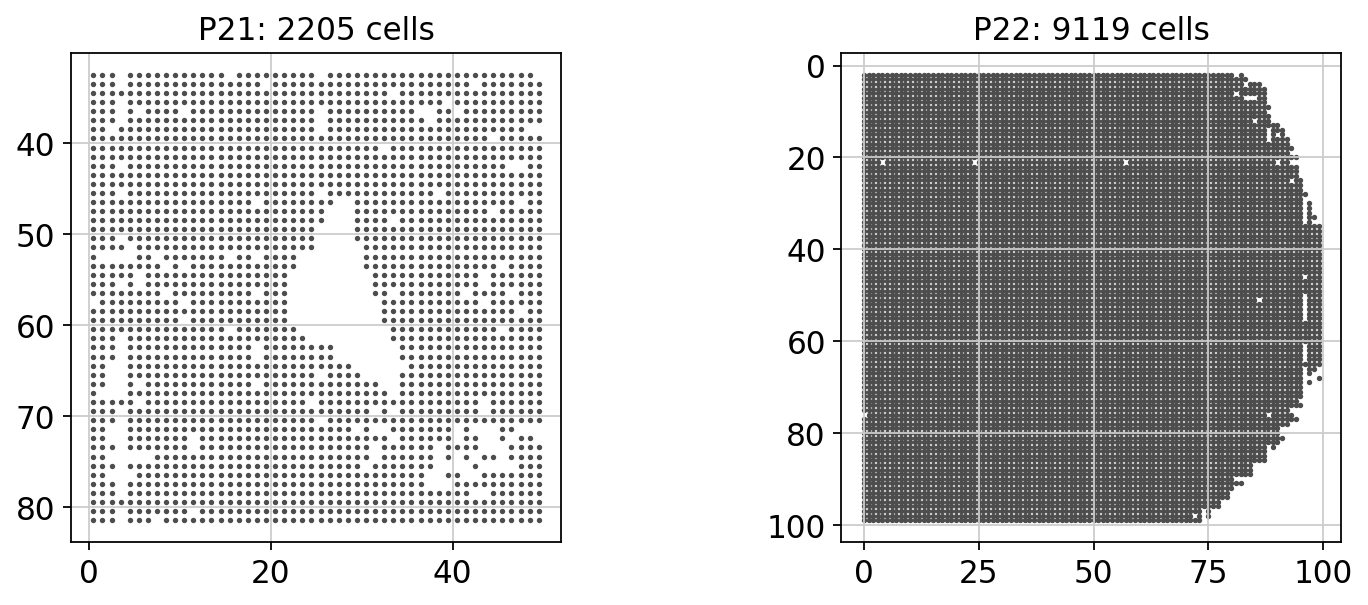

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, tp in zip(axes, ("P21", "P22")):
    sub = rna[rna.obs["timepoint"] == tp]
    ax.scatter(sub.obsm["spatial"][:, 0], sub.obsm["spatial"][:, 1],
               s=2, c="0.3")
    ax.set_aspect("equal")
    ax.set_title(f"{tp}: {sub.n_obs} cells")
    ax.invert_yaxis()
plt.tight_layout()
plt.savefig(f"{FIGURE_DIR}/raw_spatial_layout.pdf", bbox_inches="tight")
plt.show()

## 3. Spatial neighbourhood graphs

STORM consumes a k-NN spatial graph per modality. ``squidpy`` builds the
per-spot adjacency matrix ``A``; we symmetrise it explicitly.

This graph plays *two* distinct roles in STORM:

1. **Input smoothing.** A single GCN-style propagation step (see step 7
   below) lets each spot incorporate its immediate neighbours' features
   before the encoder sees them. Lightweight enough not to over-smooth.
2. **Adjacency loss target.** The training objective includes a soft
   adjacency reconstruction loss ``LGspatial`` that encourages cosine
   similarity between program-activity embeddings of neighbouring spots
   to be high, and of non-neighbouring spots to be low (negative
   sampling).

Symmetrising via the elementwise max guarantees that if spot *i* is in
*j*'s neighbourhood, then *j* is also in *i*'s, which the loss expects.

In [8]:
for adata in (rna, atac):
    sq.gr.spatial_neighbors(
        adata, coord_type="generic", spatial_key=SPATIAL_KEY, n_neighs=N_NEIGHBORS
    )
    adata.obsp[adj_key] = adata.obsp[adj_key].maximum(adata.obsp[adj_key].T)

## 4. Feature filtering and dimensionality reduction

Two design rationales here:

* **Why Moran's I and not just highly-variable feature ranking?** STORM
  is a *spatial* model: the encoder consumes a GCN-smoothed feature
  representation, so spatially structured features carry more signal
  than features with high variance but no spatial coherence.
* **Why a linear preprocessing step (PCA / LSI) before the encoder?**
  The manuscript treats this as the *first layer* of each data encoder.
  PCA (100 components) for RNA and LSI (100 components, 15 iterations)
  for ATAC compress the input to a comparable scale so the MLP encoders
  see a denser, lower-dimensional signal. Decoders still train on the
  *original* count space — only the encoder input is reduced.

Concrete steps below:

* Drop genes detected in fewer than ``MIN_CELL_GENE_THRESH_RATIO`` of
  cells.
* Keep the top ``N_SVG`` spatially variable genes by Moran's I.
* Standard normalize → log1p → scale → PCA on RNA.
* Drop rare peaks and keep the top ``N_SVP`` SV peaks; LSI on ATAC.

In [9]:
# Marker GPs (section 5) are matched against the FULL gene set, before the
# highly-variable filtering below -- this mirrors the training pipeline,
# where a marker program is kept when >15 of its genes are present among ALL
# measured genes (not just the spatially-variable subset). Snapshot the
# unfiltered RNA so the marker step in section 5 sees every gene.
_full_rna = rna.copy()

rna.layers["counts"] = rna.X.copy()
print("Filtering genes...")
sc.pp.filter_genes(rna, min_cells=int(rna.shape[0] * MIN_CELL_GENE_THRESH_RATIO))
sq.gr.spatial_autocorr(rna, mode="moran", genes=rna.var_names)
svgs = rna.uns["moranI"].index[:N_SVG].tolist()
rna.var["highly_variable"] = rna.var_names.isin(svgs)
rna = rna[:, rna.var["highly_variable"]].copy()
print(f"Kept {rna.n_vars} highly variable genes.")

sc.pp.normalize_total(rna)
sc.pp.log1p(rna)
sc.pp.scale(rna)
sc.tl.pca(rna, n_comps=100, svd_solver="auto")

print("Filtering peaks...")
sc.pp.filter_genes(atac, min_cells=int(atac.shape[0] * MIN_CELL_PEAK_THRESH_RATIO))
atac.obsp["spatial_connectivities"] = rna.obsp["spatial_connectivities"]
atac.obsp["spatial_distances"] = rna.obsp["spatial_distances"]
sq.gr.spatial_autocorr(atac, mode="moran", genes=atac.var_names)
sv_peaks = atac.uns["moranI"].index[:N_SVP].tolist()
atac.var["highly_variable"] = atac.var_names.isin(sv_peaks)
atac = atac[:, atac.var["highly_variable"]].copy()
print(f"Kept {atac.n_vars} highly variable peaks.")

nonzero = (atac.X.sum(axis=1) > 0).A1 if hasattr(atac.X, "A") else (atac.X.sum(axis=1) > 0)
atac = atac[nonzero, :].copy()
rna = rna[nonzero, :].copy()
storm.data.lsi(atac, n_components=100, n_iter=15)

Filtering genes...
Kept 3000 highly variable genes.
Filtering peaks...
Kept 15000 highly variable peaks.


## 5. Build the prior gene-program (GP) dictionary

STORM uses *masked* decoders: every latent program dimension is allowed
to reconstruct only its assigned features. The masks come from a curated
GP dictionary assembled from four prior-knowledge sources, mirroring
NicheCompass's approach:

| Source | Coverage | Source ↦ Target convention |
|--------|----------|----------------------------|
| **OmniPath** | Ligand–receptor interactions | ligand = source, receptor = target |
| **NicheNet (v2)** | Ligand → downstream target genes via the regulatory potential matrix (≤ 250 targets per program, top-ranked) | ligand = source, downstream gene = target |
| **MEBOCOST** | Metabolite-mediated signalling | metabolite-associated enzyme = source, sensor gene = target |
| **CollecTRI** | Transcription-factor → target-gene regulons | TF = source, downstream gene = target |

Every program has two halves — a **source** set (upstream signal genes)
and a **target** set (downstream response genes). STORM uses them for
*different* decoder objectives (see step 8): the **target** decoder
reconstructs the raw observed counts, while the **source** decoder
reconstructs a spatially smoothed neighbourhood feature vector. This
splits "what is this cell expressing" from "what is its neighbourhood
expressing", and is how STORM uses spatial context without smoothing the
encoder's output.

The published STORM defaults yield roughly 3,041 programs after the four
databases are combined and strict-subset programs are dropped (Chen et
al., 2026, Methods).

> **Reproducibility note.** OmniPath / NicheNet / CollecTRI are downloaded live here (``load_from_disk=False``), so the exact program set depends on the database versions on the day you run this. Two consequences: (1) marker GPs are matched on the *full* gene set (section 4) so that step is at least deterministic; (2) to analyse a *previously trained* checkpoint, reuse the preprocessing that checkpoint was trained on rather than re-deriving it here — a drifted database yields a different-sized GP dictionary and the program-activity matrix will no longer line up with the model.

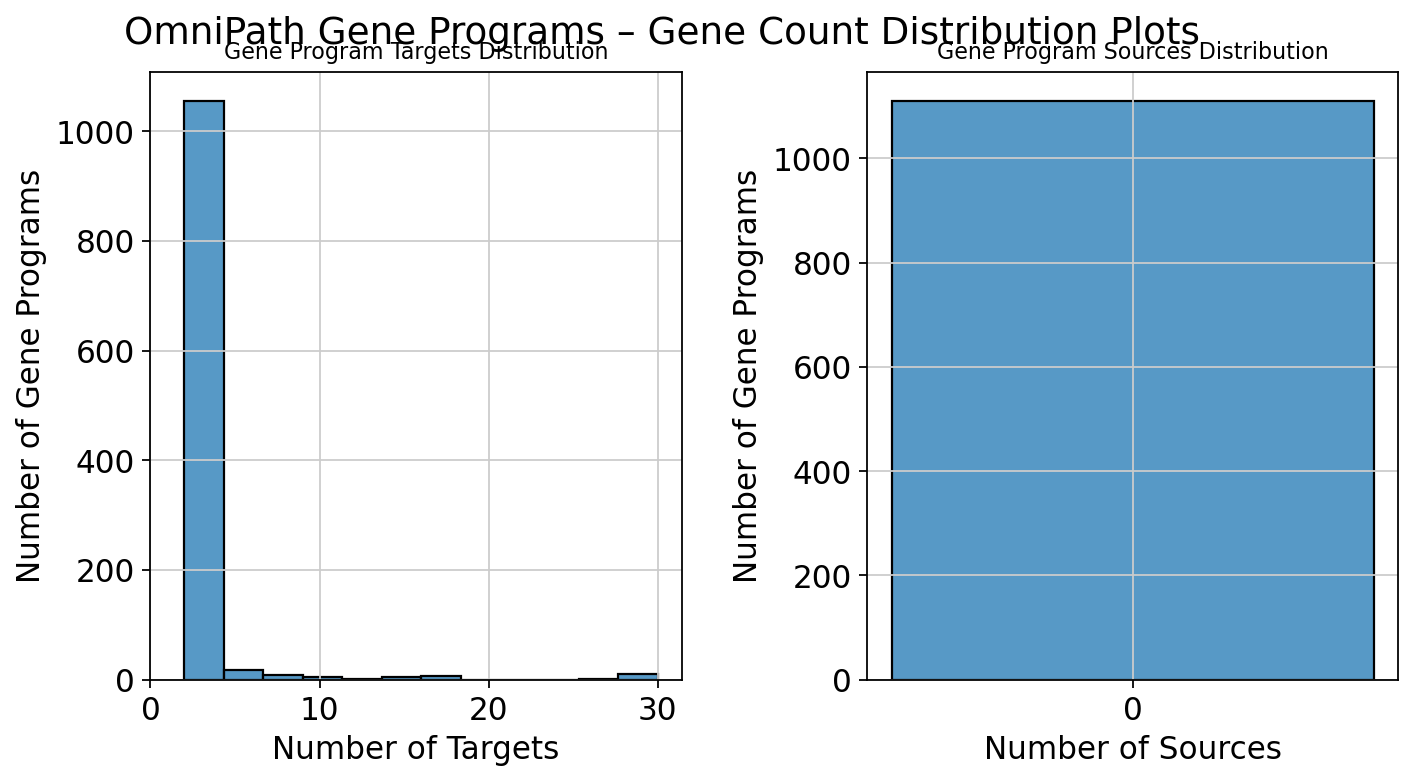

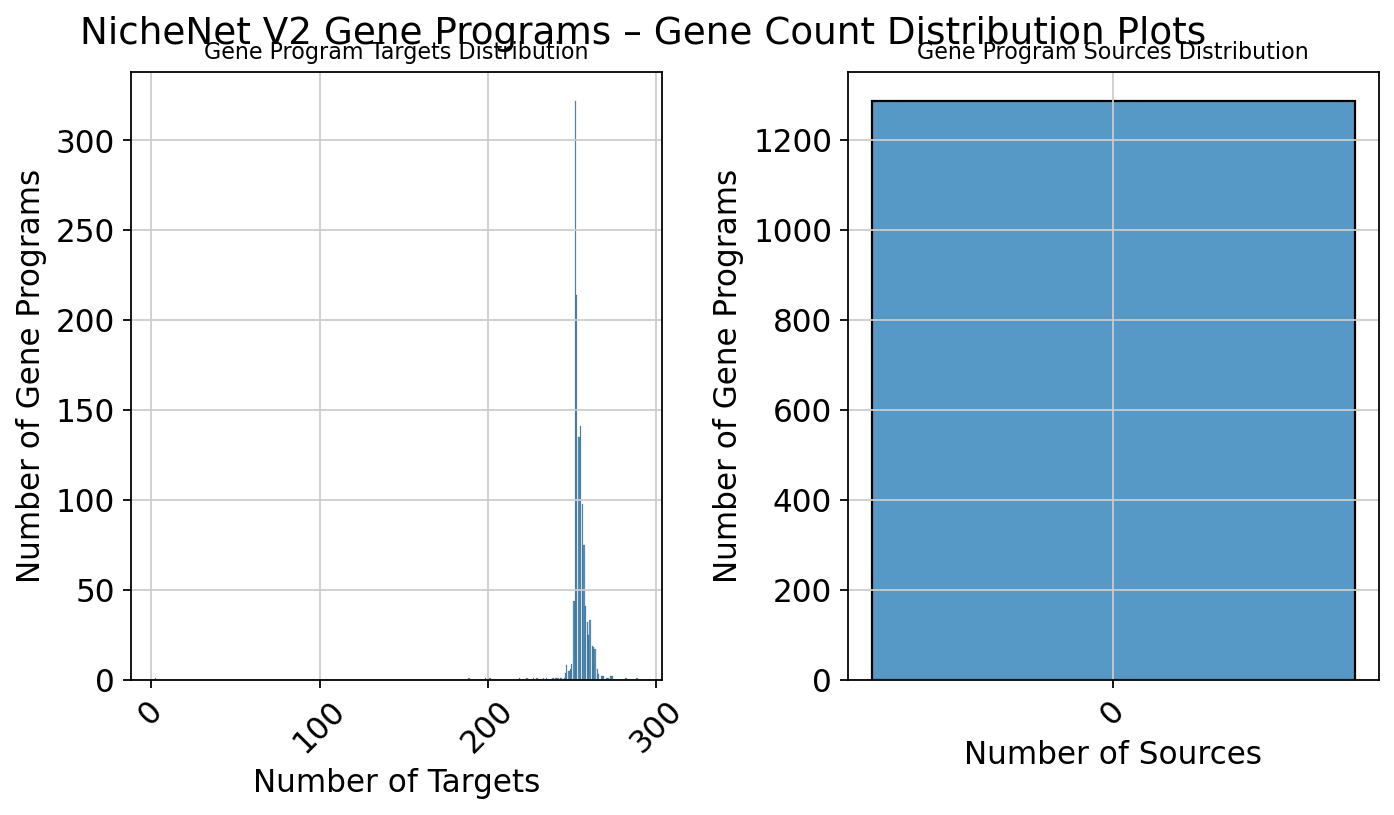

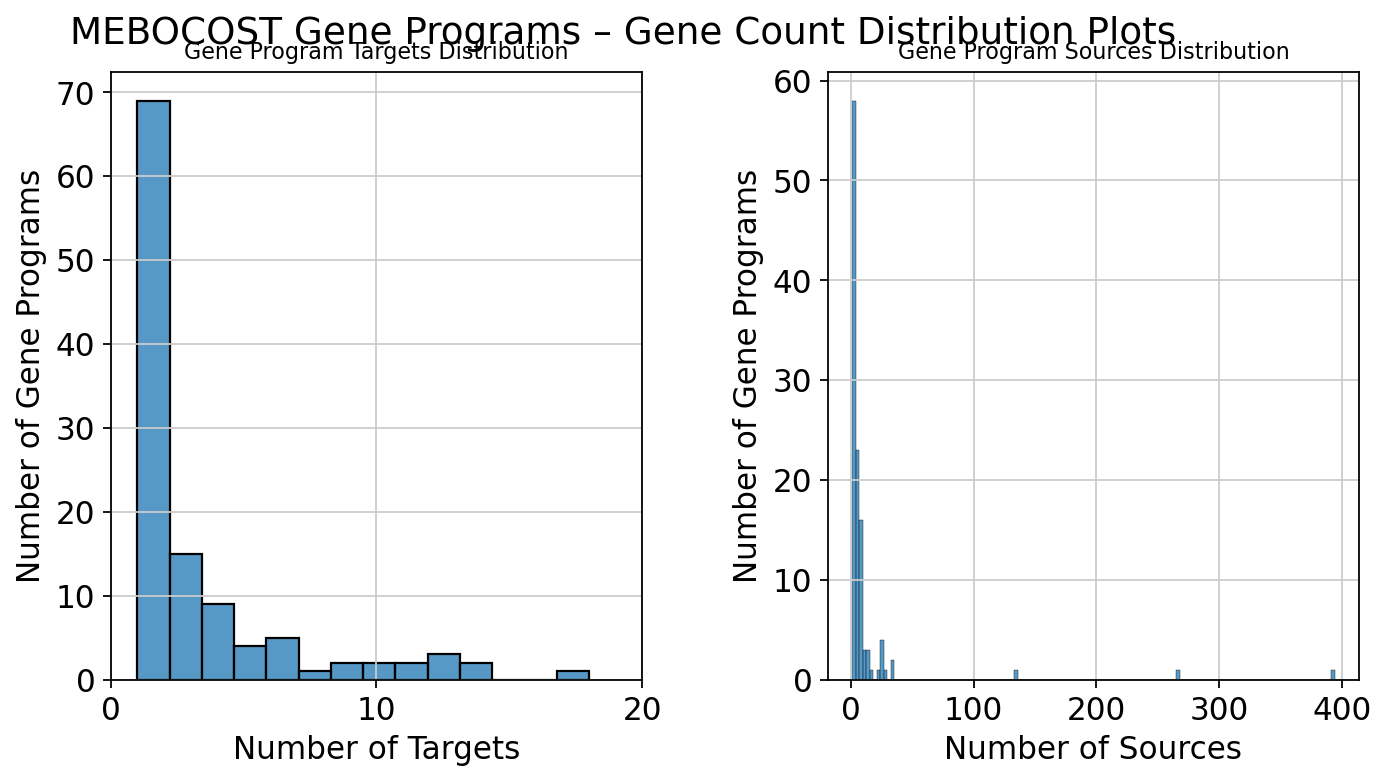

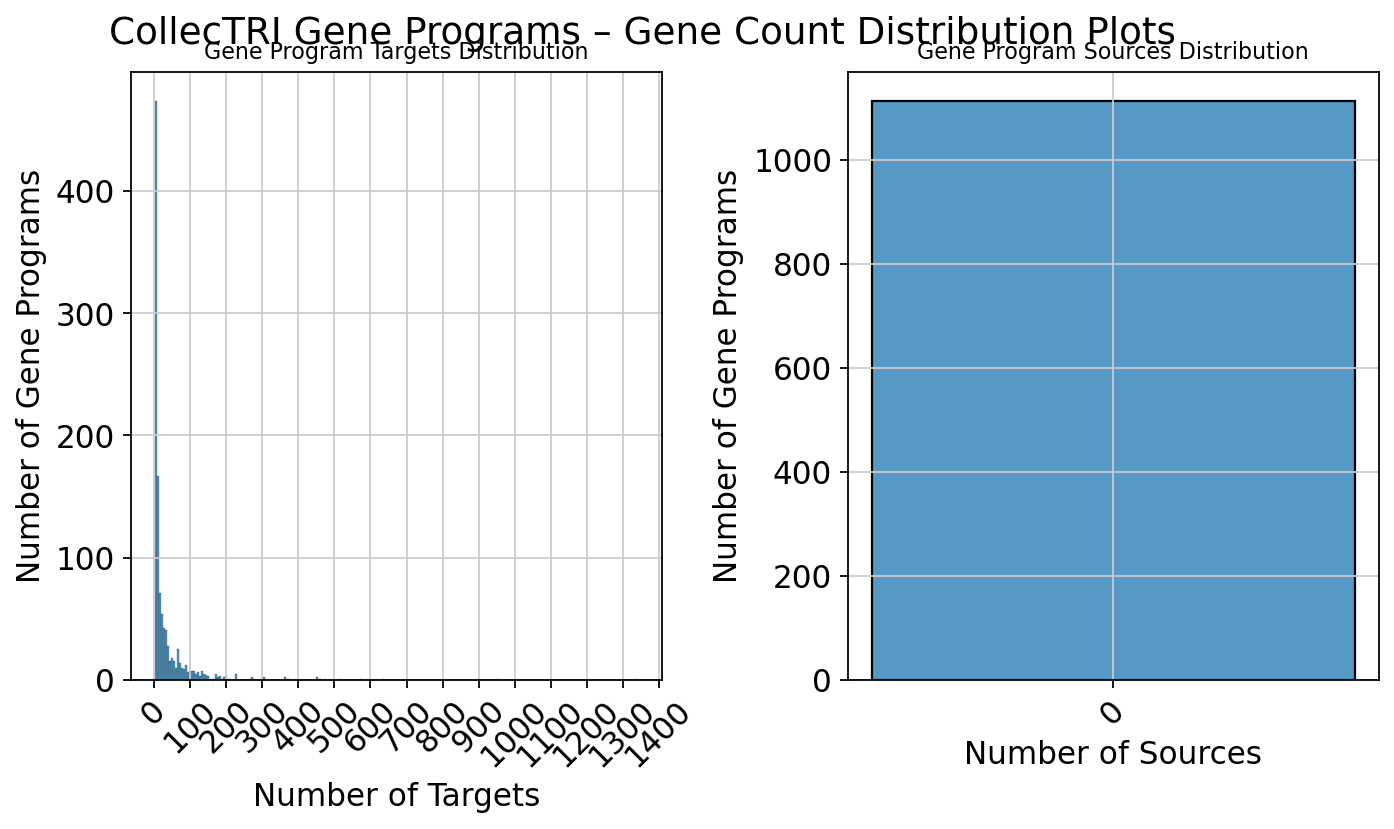

In [12]:
omnipath_gp = extract_gp_dict_from_omnipath_lr_interactions(
    species=SPECIES,
    load_from_disk=False,
    save_to_disk=True,
    lr_network_file_path=OMNIPATH_LR,
    gene_orthologs_mapping_file_path=ORTHOLOG_MAP,
    plot_gp_gene_count_distributions=True,
    gp_gene_count_distributions_save_path=f"{FIGURE_DIR}/omnipath_gp_gene_count_distributions.svg",
)

nichenet_gp = extract_gp_dict_from_nichenet_lrt_interactions(
    species=SPECIES,
    version="v2",
    keep_target_genes_ratio=1.0,
    max_n_target_genes_per_gp=250,
    load_from_disk=False,
    save_to_disk=True,
    lr_network_file_path=NICHENET_LR,
    ligand_target_matrix_file_path=NICHENET_LT,
    gene_orthologs_mapping_file_path=ORTHOLOG_MAP,
    plot_gp_gene_count_distributions=True,
)

mebocost_gp = extract_gp_dict_from_mebocost_ms_interactions(
    dir_path=MEBOCOST_DIR,
    species=SPECIES,
    plot_gp_gene_count_distributions=True,
)

collectri_gp = extract_gp_dict_from_collectri_tf_network(
    species=SPECIES,
    tf_network_file_path=COLLECTRI_TF,
    load_from_disk=False,
    save_to_disk=True,
    plot_gp_gene_count_distributions=True,
)

### Cell-type marker GPs

We additionally fold in the top 150 marker genes per cluster from a
single-cell brain reference (Zeisel et al., 2018) as ~160 cell-type
"anchor" programs. These are **training-stability scaffolds** — they
give the model enough signal early in training to settle into
biologically sensible clusters — and are flagged so they can be excluded
from downstream gene-program *discovery* analyses.

In [13]:
def extract_gp_dict_from_csv(
    adata, csv_file, min_genes=0, max_genes=None,
    varm_key="I", uns_key="terms", genes_use_upper=True,
):
    df = pd.read_csv(csv_file)
    if genes_use_upper:
        df["names"] = df["names"].str.upper()
        var_names = adata.var_names.str.upper()
    else:
        var_names = adata.var_names

    groups = df["group"].unique()
    indicator = np.zeros((len(var_names), len(groups)), dtype=int)
    gp_dict = {}
    for j, group in enumerate(groups):
        group_genes = df[df["group"] == group]["names"]
        mask = var_names.isin(group_genes)
        indicator[:, j] = mask.astype(int)
        gene_count = mask.sum()
        if gene_count > min_genes and (max_genes is None or gene_count < max_genes):
            target_genes = var_names[mask]
            gp_dict[group] = {
                "sources": [],
                "sources_categories": [],
                "targets": list(target_genes),
                "targets_categories": ["target_gene"] * len(target_genes),
            }
        else:
            indicator[:, j] = 0
    valid = indicator.sum(0) > 0
    adata.varm[varm_key] = indicator[:, valid]
    adata.uns[uns_key] = list(groups[valid])
    return gp_dict


# Build marker GPs from the full (pre-filtering) gene set captured in
# section 4, so a program is retained when >15 of its markers are present
# among ALL measured genes. Calling this on the HVG-filtered `rna` silently
# drops programs whose markers are mostly non-spatially-variable (~11 in the
# published 2-timepoint run), which is what made a converted checkpoint's GP
# count disagree with this notebook's output.
marker_gp = extract_gp_dict_from_csv(_full_rna, MARKER_CSV, min_genes=15)
del _full_rna

combined_gp_dict = filter_and_combine_gp_dict_gps_v2(
    [marker_gp, omnipath_gp, nichenet_gp, mebocost_gp, collectri_gp],
    verbose=False,
)
print(f"Combined GP dictionary contains {len(combined_gp_dict)} programs.")

Combined GP dictionary contains 3134 programs.


## 6. RNA-anchored feature guidance graph

The guidance graph ``G_features`` lives on the *feature* side: nodes are
genes ∪ peaks, edges encode prior regulatory beliefs about which peaks
regulate which genes.

* **Edges** are built from genomic position overlap: an ATAC peak
  overlapping a gene body or its promoter window (default ±2 kb of the
  TSS) gets a positive edge to the gene.
* **Edge signs** (``±1``) indicate the direction of the regulatory
  interaction (e.g. promoter-proximal peak → gene is ``+1``).
* **Edge weights** (``∈ (0, 1]``) are interpreted as credibility — a
  peak far from a gene gets a small weight.
* Self-loops are added with sign / weight ``= 1`` for numerical
  stability.

STORM's **graph encoder** (a GCN) maps this graph into feature
embeddings ``V``; the **graph decoder** is an inner-product +
negative-sampling Bernoulli model on edges. Maximising the graph
likelihood pulls connected features (e.g. a peak and its target gene)
toward similar embeddings, which is what couples the two modality
decoders.

In [14]:
storm.data.get_gene_annotation(rna, gtf=GTF_PATH, gtf_by="gene_name")

split = atac.var_names.str.split(r"[:-]")
atac.var["chrom"] = split.map(lambda x: x[0])
atac.var["chromStart"] = split.map(lambda x: x[1]).astype(int)
atac.var["chromEnd"] = split.map(lambda x: x[2]).astype(int)


def gtf_gene_names(file_path):
    cols = ["seqname", "source", "feature", "start", "end",
            "score", "strand", "frame", "attribute"]
    df = pd.read_csv(file_path, sep="\t", comment="#", names=cols)
    return df["attribute"].str.extract('gene_name "([^"]+)"')[0]


gene_names_in_gtf = set(gtf_gene_names(GTF_PATH).dropna())
rna = rna[:, rna.var_names.isin(gene_names_in_gtf)].copy()

guidance = storm.genomics.rna_anchored_guidance_graph(rna, atac)
storm.graph.check_graph(guidance, [rna, atac])

window_graph:   0%|          | 0/2871 [00:00<?, ?it/s]

[INFO] check_graph: Checking variable coverage...


INFO:check_graph:Checking variable coverage...


[INFO] check_graph: Checking edge attributes...


INFO:check_graph:Checking edge attributes...


...

INFO:check_graph:Checking self-loops...


[INFO] check_graph: Checking graph symmetry...


INFO:check_graph:Checking graph symmetry...


[INFO] check_graph: All checks passed!


INFO:check_graph:All checks passed!


## 7. Spatial-smoothed feature representations

This is the one-step GCN propagation that injects local tissue context
into the encoder input:

$$
\tilde{A} = A + I,\quad
H = \tilde{D}^{-1/2}\,\tilde{A}\,\tilde{D}^{-1/2},\quad
X_\text{spa} = H \cdot X_\text{pca}
$$

In plain English: each spot's PCA / LSI vector is averaged with its
neighbours' vectors via the symmetrically normalised spatial adjacency
``H``. One pass, no learnable parameters — enough to give the encoder a
denoised, neighbourhood-aware view without dominating the signal with
spatial structure.

We also stash ``adj`` itself into ``adata.obsm['spatial_adj']``; the
model reads it from there to compute the spatial adjacency loss
``LGspatial`` during training.

In [15]:
def construct_interaction(spatial, n_neighbors=17):
    distance_matrix = ot.dist(spatial, spatial, metric="euclidean")
    n_spot = distance_matrix.shape[0]
    interaction = np.zeros([n_spot, n_spot])
    for i in range(n_spot):
        order = distance_matrix[i, :].argsort()
        for t in range(1, n_neighbors + 1):
            interaction[i, order[t]] = 1
    adj = interaction + interaction.T
    return np.where(adj > 1, 1, adj)


def normalize_adj(adj):
    adj = sp.coo_matrix(adj)
    rowsum = np.array(adj.sum(1))
    d_inv_sqrt = np.power(rowsum, -0.5).flatten()
    d_inv_sqrt[np.isinf(d_inv_sqrt)] = 0.0
    d = sp.diags(d_inv_sqrt)
    return adj.dot(d).transpose().dot(d).toarray()


def preprocess_adj(adj):
    return normalize_adj(adj) + np.eye(adj.shape[0])


for adata, rep_key in ((rna, "X_pca"), (atac, "X_lsi")):
    adj = preprocess_adj(construct_interaction(adata.obsm["spatial"]))
    adata.obsm["spatial_adj"] = adj
    adata.obsm["X_spa"] = adj @ adata.obsm[rep_key]

## 8. Attach the GP masks to ``adata.varm``

``add_gps_from_gp_dict_to_adata`` writes one column per GP into
``adata.varm`` for both the *targets* and *sources* axes. Concretely it
produces the two binary membership matrices

* ``M_m ∈ {0,1}^{|V_m| × N_gp}`` — **target** mask: gene/peak *i*
  belongs to the target set of program *j*.
* ``M_m' ∈ {0,1}^{|V_m| × N_gp}`` — **source** mask: gene/peak *i*
  belongs to the source set of program *j*.

These masks are elementwise-applied to the decoder weights at training
time, so each program dimension can only reconstruct its own features
(no cross-program leakage).

The keys use the ``storm_*`` prefix throughout — :class:`storm.models.STORMModel`
looks them up under those names by default (override via the
``anndata_keys`` constructor argument; see
:data:`storm.models.STORM_DEFAULT_KEYS`).

In [ ]:
add_gps_from_gp_dict_to_adata(
    gp_dict=combined_gp_dict,
    adata=rna,
    gp_targets_mask_key=storm_gp_targets_mask_key,
    gp_targets_categories_mask_key=storm_gp_targets_categories_mask_key,
    gp_sources_mask_key=storm_gp_sources_mask_key,
    gp_sources_categories_mask_key=storm_gp_sources_categories_mask_key,
    gp_names_key=storm_gp_names_key,
    min_genes_per_gp=1,
    min_source_genes_per_gp=0,
    min_target_genes_per_gp=1,
    max_genes_per_gp=None,
    max_source_genes_per_gp=None,
    max_target_genes_per_gp=None,
    plot_gp_gene_count_distributions=True,
)

gene_peak_mapping = generate_multimodal_mapping_dict(adata=rna, adata_atac=atac)
with open(PREP_MAPPING, "w", encoding="utf-8") as f:
    json.dump(gene_peak_mapping, f, ensure_ascii=False, indent=2, sort_keys=True)

rna, atac = add_multimodal_mask_to_adata(
    adata=rna,
    adata_atac=atac,
    gene_peak_mapping_dict=gene_peak_mapping,
)
print(f"After multimodal masking: {atac.n_vars} peaks remain.")

## 9. Save the preprocessed AnnDatas and guidance graph

Tutorial 2 (training) loads these three artifacts and skips everything
above. Everything STORM needs on the input side is now packaged inside
the two ``.h5ad`` files and the ``guidance.graphml.gz`` graph.

In [ ]:
rna.write(PREP_RNA, compression="gzip")
atac.write(PREP_ATAC, compression="gzip")
nx.write_graphml(guidance, PREP_GRAPH)

print(f"Wrote {PREP_RNA}")
print(f"Wrote {PREP_ATAC}")
print(f"Wrote {PREP_GRAPH}")
print(f"Wrote {PREP_MAPPING}")
print()
print("Final RNA:", rna)
print("Final ATAC:", atac)